In [1]:
!pip install dezero

## 정책 신경망을 2층 완전 연결 모델로 구현

In [2]:
import numpy as np
import gymnasium as gym
np.int = int
np.float = float
from dezero import Model
from dezero import optimizers
import dezero.functions as F
import dezero.layers as L

class Policy(Model):
    def __init__(self, action_size):
        super().__init__()
        self.l1 = L.Linear(128)
        self.l2 = L.Linear(action_size)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.softmax(self.l2(x))
        return x    

In [3]:
class Agent:
    def __init__(self):
        self.gamma = 0.98
        self.lr = 0.0002
        self.action_size = 2

        self.memory = []
        self.pi = Policy(self.action_size)
        self.optimizer = optimizers.Adam(self.lr)
        self.optimizer.setup(self.pi)

    def get_action(self, state):
        if isinstance(state, tuple):
            state = state[0]
            
        state = state[np.newaxis, :]
        probs = self.pi(state)
        probs = probs[0]
        action = np.random.choice(len(probs), p=probs.data)
        return action, probs[action]

    def add(self, reward, prob):
        data = (reward, prob)
        self.memory.append(data)

    def update(self):
        self.pi.cleargrads()

        G, loss = 0, 0
        for reward, prob in reversed(self.memory):
            G = reward + self.gamma * G

        for reward, prob in self.memory:
            loss += - F.log(prob) * G

        loss.backward()
        self.optimizer.update()
        self.memory = []


In [4]:
env = gym.make('CartPole-v1',render_mode = 'rgb_array')
state = env.reset()[0]
agent = Agent()

action , prob = agent.get_action(state)
print(f"행동:{action}")
print(f"확률:{prob}")

G = 100.0
J = G * F.log(prob)
print(F"J:{J}")

J.backward()

행동:1
확률:variable(0.49308966581885194)
J:variable(-70.70642435485264)


In [7]:
import matplotlib.pyplot as plt

def plot_total_reward(reward_history):
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.plot(range(len(reward_history)), reward_history)
    plt.show()

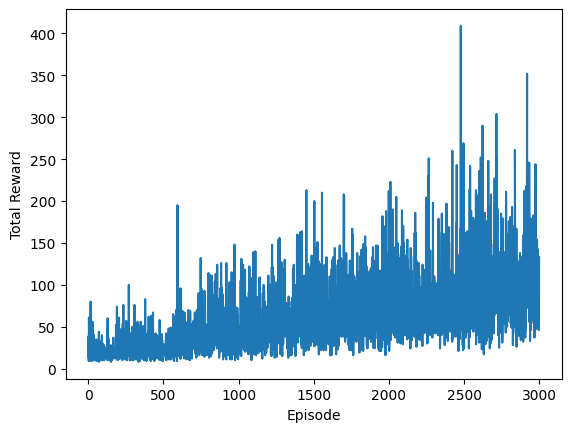

In [8]:
episodes = 3000
env = gym.make('CartPole-v1',render_mode = 'rgb_array')
agent = Agent()
reward_history = []

for episode in range(episodes):
    state = env.reset()[0]
    done = False
    total_reward = 0

    while not done:
        action, prob = agent.get_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated | truncated

        agent.add(reward, prob)
        state = next_state
        total_reward += reward

    agent.update()
    reward_history.append(total_reward)


plot_total_reward(reward_history)        

## Agent : REINFORCE Algorithm
- 너무 오래걸려서 PyTorch 버전으로 다시...

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [16]:
class Policy(nn.Module):
    def __init__(self,action_size):
        super(Policy, self).__init__()
        self.l1 = nn.Linear(4, 128)
        self.l2 = nn.Linear(128, action_size)

    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.softmax(self.l2(x), dim = 1)
        return x    

In [14]:
class Agent:
    def __init__(self):
        self.gamma = 0.98
        self.lr = 0.0002
        self.action_size = 2
        self.memory = []
        self.pi = Policy(self.action_size)
        self.optimizer = optim.Adam(self.pi.parameters(), lr=self.lr)
    def get_action(self, state):
        if isinstance(state, tuple):
            state = state[0]
            
    
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        
        probs = self.pi(state)
        
    
        m = Categorical(probs)
        action = m.sample()
        
        return action.item(), probs[0, action.item()]
    def add(self, reward, prob):
        data = (reward, prob)
        self.memory.append(data)
    def update(self):
        G, loss = 0, 0
        

        for reward, prob in reversed(self.memory):
            G = reward + self.gamma * G
            loss += - torch.log(prob) * G
 
        loss.backward() 
 
        self.optimizer.step() 
        
        self.memory = []

In [17]:
episodes = 3000
env = gym.make('CartPole-v1') 
agent = Agent()
reward_history = []
for episode in range(episodes):
    state = env.reset()[0]
    done = False
    total_reward = 0
    while not done:
        action, prob = agent.get_action(state)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated | truncated
        agent.add(reward, prob)
        state = next_state
        total_reward += reward
    agent.update()
    reward_history.append(total_reward)
    
    if (episode + 1) % 100 == 0:
        print(f"Episode {episode + 1} / {episodes}: Total Reward = {total_reward}")

Episode 100 / 3000: Total Reward = 65.0
Episode 200 / 3000: Total Reward = 108.0
Episode 300 / 3000: Total Reward = 62.0
Episode 400 / 3000: Total Reward = 237.0
Episode 500 / 3000: Total Reward = 122.0
Episode 600 / 3000: Total Reward = 199.0
Episode 700 / 3000: Total Reward = 256.0
Episode 800 / 3000: Total Reward = 500.0
Episode 900 / 3000: Total Reward = 358.0
Episode 1000 / 3000: Total Reward = 332.0
Episode 1100 / 3000: Total Reward = 271.0
Episode 1200 / 3000: Total Reward = 210.0
Episode 1300 / 3000: Total Reward = 265.0
Episode 1400 / 3000: Total Reward = 315.0
Episode 1500 / 3000: Total Reward = 500.0
Episode 1600 / 3000: Total Reward = 500.0
Episode 1700 / 3000: Total Reward = 500.0
Episode 1800 / 3000: Total Reward = 500.0
Episode 1900 / 3000: Total Reward = 500.0
Episode 2000 / 3000: Total Reward = 500.0
Episode 2100 / 3000: Total Reward = 500.0
Episode 2200 / 3000: Total Reward = 500.0
Episode 2300 / 3000: Total Reward = 299.0
Episode 2400 / 3000: Total Reward = 344.0
Epi

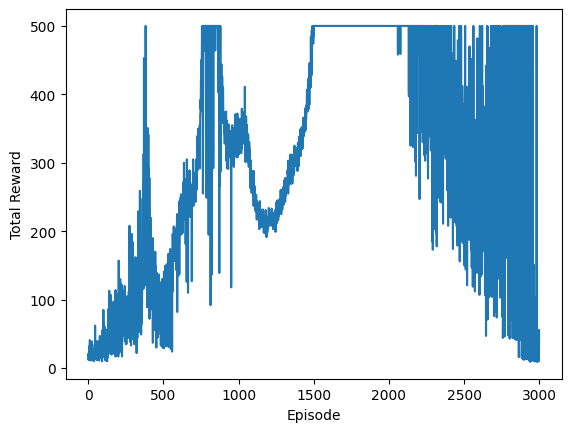

In [18]:
def plot_total_reward(reward_history):
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.plot(range(len(reward_history)), reward_history)
    plt.show()
plot_total_reward(reward_history)